In [2]:
pip install google-cloud-bigquery pandas plotly

In [ ]:
pip install db-dtypes

In [2]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:/Users/muham/Desktop/Noora_Health_Assignement/noora_health_json_key/noorahealth-488108-7ad5e140ef9f.json"

from google.cloud import bigquery
client = bigquery.Client()

In [ ]:
import warnings
warnings.filterwarnings('ignore')import warnings
warnings.filterwarnings('ignore')

***Total Users vs Active Users Over Time***

Definitions:

Total users = distinct users who sent OR received a message

Active users = distinct users who sent inbound messages

In [17]:
query_users = """
WITH base AS (
  SELECT
    DATE_TRUNC(DATE(message_inserted_at), WEEK) AS week,
    CASE
      WHEN direction = 'inbound' THEN masked_author
      WHEN direction = 'outbound' THEN masked_addressees
    END AS user_id,
    direction
  FROM `noorahealth-488108.noora_health_analytics.messages_enriched`
)

SELECT
  week,
  COUNT(DISTINCT user_id) AS total_users,
  COUNT(DISTINCT IF(direction = 'inbound', user_id, NULL)) AS active_users
FROM base
GROUP BY week
ORDER BY week
"""

df_users = client.query(query_users).to_dataframe()
df_users.head()

,week,total_users,active_users
0,2019-09-15,1,0
1,2019-09-22,2,0
2,2019-09-29,4,1
3,2019-10-06,8,0
4,2019-10-13,11,0


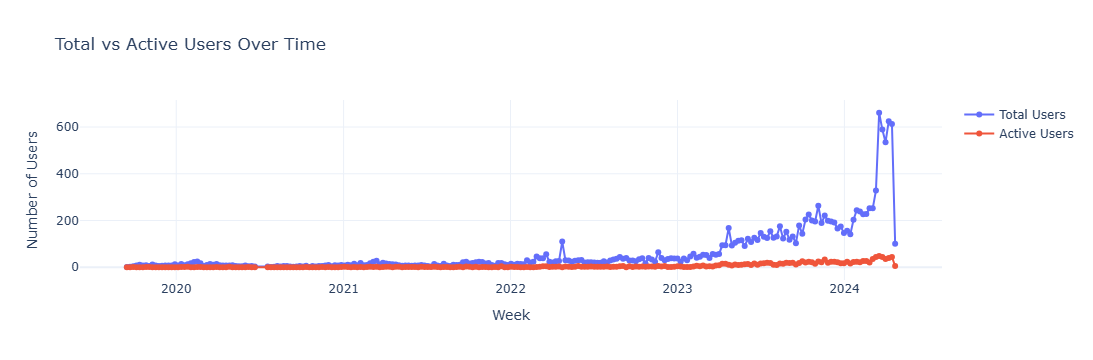

In [8]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_users["week"],
    y=df_users["total_users"],
    mode="lines+markers",
    name="Total Users"
))

fig.add_trace(go.Scatter(
    x=df_users["week"],
    y=df_users["active_users"],
    mode="lines+markers",
    name="Active Users"
))

fig.update_layout(
    title="Total vs Active Users Over Time",
    xaxis_title="Week",
    yaxis_title="Number of Users",
    template="plotly_white"
)

fig.show()

***Fraction of Non-Failed Outbound Messages That Were Read***

Definition:

Considered outbound messages only

Excluded messages with status "failed"

In [18]:
query_read_rate = """
WITH flattened AS (
  SELECT
    message_id,
    direction,
    s.status
  FROM `noorahealth-488108.noora_health_analytics.messages_enriched`,
  UNNEST(status_events) s
  WHERE direction = 'outbound'
)

SELECT
  COUNT(DISTINCT IF(status != 'failed', message_id, NULL)) AS non_failed,
  COUNT(DISTINCT IF(status = 'read', message_id, NULL)) AS read_messages
FROM flattened
"""

df_read = client.query(query_read_rate).to_dataframe()

read_rate = df_read["read_messages"][0] / df_read["non_failed"][0]
read_rate

np.float64(0.8758085381630013)

In [10]:
print(f"Read Rate: {read_rate:.2%}")

Read Rate: 87.58%


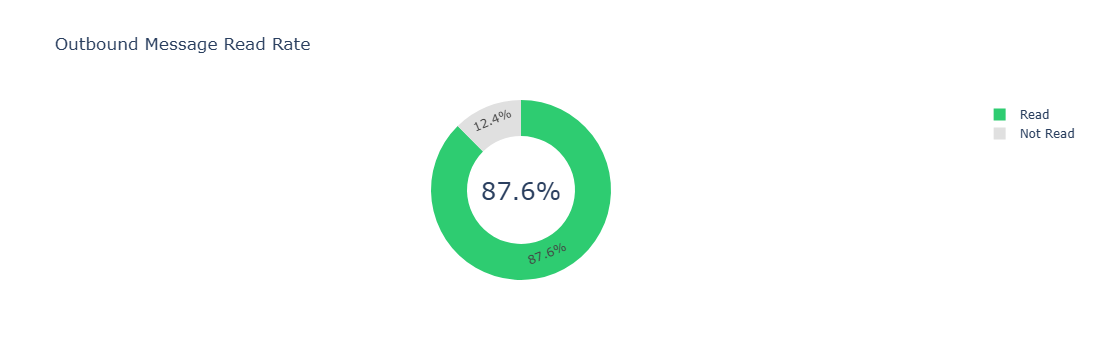

In [13]:
import plotly.graph_objects as go

labels = ["Read", "Not Read"]
values = [df_read["read_messages"][0], df_read["non_failed"][0] - df_read["read_messages"][0]]

fig = go.Figure(go.Pie(
    labels=labels,
    values=values,
    hole=0.6,
    marker_colors=["#2ecc71", "#e0e0e0"]
))

fig.update_layout(
    title="Outbound Message Read Rate",
    annotations=[dict(text=f"{values[0]/sum(values):.1%}", font_size=24, showarrow=False)]
)

fig.show()

***Distribution of Time Between Sent and Read***

read_timestamp - sent_timestamp

In [19]:
query_read_time = """
WITH flattened AS (
  SELECT
    message_id,
    s.status,
    s.timestamp
  FROM `noorahealth-488108.noora_health_analytics.messages_enriched`,
  UNNEST(status_events) s
  WHERE direction = 'outbound'
),

sent_times AS (
  SELECT
    message_id,
    MIN(timestamp) AS sent_time
  FROM flattened
  WHERE status = 'sent'
  GROUP BY message_id
),

read_times AS (
  SELECT
    message_id,
    MIN(timestamp) AS read_time
  FROM flattened
  WHERE status = 'read'
  GROUP BY message_id
)

SELECT
  TIMESTAMP_DIFF(r.read_time, s.sent_time, SECOND) AS seconds_to_read
FROM sent_times s
JOIN read_times r
  ON s.message_id = r.message_id
WHERE r.read_time IS NOT NULL
"""

df_read_time = client.query(query_read_time).to_dataframe()
df_read_time.head()

,seconds_to_read
0,11743
1,1493
2,60549
3,9
4,733535


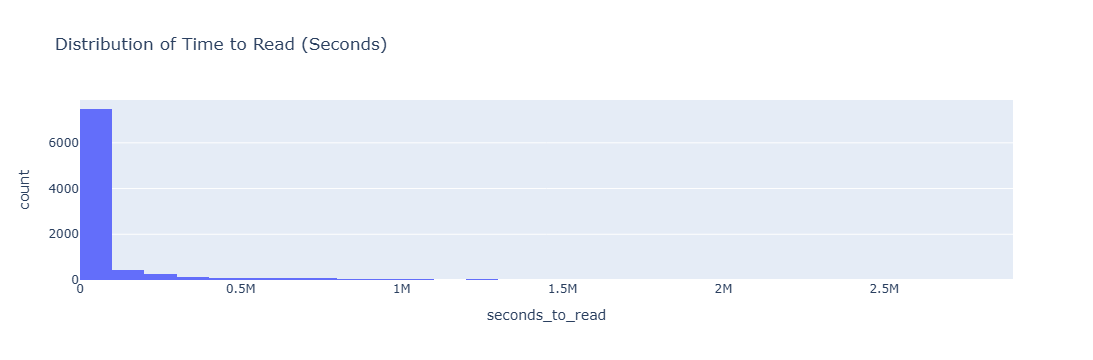

In [12]:
import plotly.express as px

fig = px.histogram(
    df_read_time,
    x="seconds_to_read",
    nbins=50,
    title="Distribution of Time to Read (Seconds)"
)

fig.show()

***Outbound Messages in the Last Week by Status***

In [23]:
query_last_week = """
WITH flattened AS (
  SELECT
    DATE(s.timestamp) AS status_date,
    s.status
  FROM `noorahealth-488108.noora_health_analytics.messages_enriched`,
  UNNEST(status_events) s
  WHERE direction = 'outbound'
),

max_date AS (
  SELECT MAX(status_date) AS max_status_date
  FROM flattened
)

SELECT
  f.status,
  COUNT(*) AS message_count
FROM flattened f
CROSS JOIN max_date m
WHERE f.status_date BETWEEN DATE_SUB(m.max_status_date, INTERVAL 6 DAY)
                         AND m.max_status_date
GROUP BY f.status
ORDER BY message_count DESC
"""

df_last_week = client.query(query_last_week).to_dataframe()
df_last_week

,status,message_count
0,sent,485
1,read,472
2,delivered,469
3,failed,24


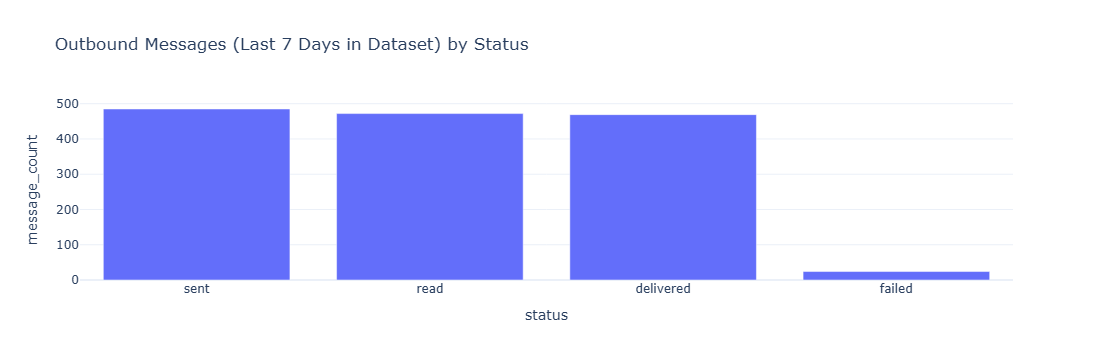

In [24]:
import plotly.express as px

fig = px.bar(
    df_last_week,
    x="status",
    y="message_count",
    title="Outbound Messages (Last 7 Days in Dataset) by Status",
    template="plotly_white"
)

fig.show()